# The North Face ecommerce


## Contexte
Le service marketing de The North Face veut augmenter les ventes sur son site web. Deux pistes :
- un système de recommandation ("vous pourriez aussi aimer…") sur chaque page produit ;
- une meilleure structure du catalogue, en utilisant des méthodes non supervisées pour trouver de nouvelles catégories de produits.

## Objectifs
 - Identifier des groupes de produits qui ont des descriptions similaires (clustering).
 - Utiliser ces groupes pour construire faire des recommandations.
 - Trouver les thèmes cachés dans les descriptions avec du topic extraction 

## Plan du notebook
 - Prétraitement du texte et encodage
 - Partie 1 : groupes de produits avec des descriptions similaires (clustering)
 - Partie 2 : système de recommandation
 - Partie 3 : topic modeling



In [1]:
import pandas as pd
import numpy as np

from bs4 import BeautifulSoup
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt
from wordcloud import WordCloud


# Prétraitement et encodage du texte #

In [2]:

data = pd.read_csv('sample-data.csv')
print(data.shape)
data.head()

(500, 2)


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [3]:
print(data['description'][0])

Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a travel pack. An exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. Made of 3.7-oz 100% recycled polyester with moisture-wicking performance. Inseam (size M) is 4 1/2". Recyclable through the Common Threads Recycling Program.<br><br><b>Details:</b><ul> <li>"Silky Capilene 1 fabric is ultralight, breathable and quick-to-dry"</li> <li>"Exposed, brushed elastic waistband for comfort"</li> <li>5-panel construction with traditional boxer back</li> <li>"Inseam (size M) is 4 1/2"""</li></ul><br><br><b>Fabric: </b>3.7-oz 100% all-recycled polyester with Gladiodor natural odor control for the garment. Recyclable through the Common Threads Recycling Program<br><br><b>Weight: </b>99 g (3.5 oz)<br><br>

### Nettoyage du texte

Point de vigilance : on voit que le texte comprend des balises html. On va donc utiliser BeautifulSoup pour les supprimer. La tokenisation et lemmatisation se feront avec spaCy.

In [4]:
nlp = spacy.load('en_core_web_sm')

In [5]:
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text(separator=' ')
    
    text = text.lower()
    
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop        
        and not token.is_punct      
        and not token.is_space      
        and token.is_alpha          
            ]
    
    return ' '.join(tokens)

In [6]:
print(data['description'][0])
print('---')
print(clean_text(data['description'][0]))

Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a travel pack. An exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. Made of 3.7-oz 100% recycled polyester with moisture-wicking performance. Inseam (size M) is 4 1/2". Recyclable through the Common Threads Recycling Program.<br><br><b>Details:</b><ul> <li>"Silky Capilene 1 fabric is ultralight, breathable and quick-to-dry"</li> <li>"Exposed, brushed elastic waistband for comfort"</li> <li>5-panel construction with traditional boxer back</li> <li>"Inseam (size M) is 4 1/2"""</li></ul><br><br><b>Fabric: </b>3.7-oz 100% all-recycled polyester with Gladiodor natural odor control for the garment. Recyclable through the Common Threads Recycling Program<br><br><b>Weight: </b>99 g (3.5 oz)<br><br>

In [7]:
data['description_clean'] = data['description'].apply(clean_text)
data[['description', 'description_clean']].head()

,description,description_clean
0,Active classic boxers - There's a reason why o...,active classic boxer reason boxer cult favorit...
1,Active sport boxer briefs - Skinning up Glory ...,active sport boxer brief skin glory require mo...
2,Active sport briefs - These superbreathable no...,active sport brief superbreathable fly brief m...
3,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pant skin climb ice switch rock t...
4,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt high ridge steep ice alpine ja...


In [8]:
data['description_clean'].apply(len).min(), (data['description_clean'] == '').sum()

(np.int64(187), np.int64(0))

### Encodage du texte

In [9]:
MIN_DF = 2
MAX_DF = 0.8
MAX_FEATURES = 1000

tfidf = TfidfVectorizer(min_df=MIN_DF, max_df=MAX_DF, max_features=MAX_FEATURES)
X = tfidf.fit_transform(data['description_clean'])
X.shape

(500, 1000)


## Partie 1 : groupes de produits avec des descriptions similaires (clustering)

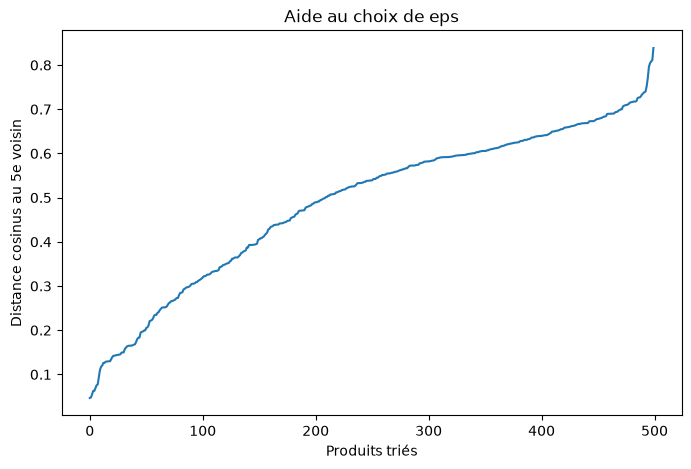

In [10]:
nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(X)

distances, _ = nn.kneighbors(X)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel('Produits triés')
plt.ylabel('Distance cosinus au 5e voisin')
plt.title('Aide au choix de eps')
plt.show()

Pas de coude net sur la courbe. 
On cherche eps entre 0.5 et 0.7 pour avoir un nombre de clusters entre 10 et 20 et pas trop d'outliers.

In [11]:
eps_values = np.round(np.arange(0.5, 0.71, 0.02), 2)

results = []

for min_samples in [3, 4, 5]:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit_predict(X)

        n_clusters = labels.max() + 1
        
        n_outliers = (labels == -1).sum()

        results.append({
            'min_samples': min_samples,
            'eps': eps,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers
        })


In [12]:
results_df = pd.DataFrame(results)
results_df.head()

,min_samples,eps,n_clusters,n_outliers
0,3,0.50,40,159
1,3,0.52,42,123
2,3,0.54,38,105
3,3,0.56,36,83
4,3,0.58,25,58


In [13]:
results_df = results_df[(results_df['n_clusters']>=10) & (results_df['n_clusters']<=20)]
results_df.sort_values('n_outliers')

,min_samples,eps,n_clusters,n_outliers
7,3,0.64,12,15
18,4,0.64,12,24
6,3,0.62,14,32
5,3,0.60,20,41
17,4,0.62,14,42
29,5,0.64,12,42
16,4,0.60,20,54
28,5,0.62,14,58
27,5,0.60,20,79
23,5,0.52,20,223


Pour avoir un nombre de clusters entre 10 et 20 tout en minimisant les outliers, on choir eps = 0.64 et min_samples=3

In [14]:
EPS = 0.64
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='cosine')
data['cluster_dbscan'] = dbscan.fit_predict(X)

In [15]:
data['cluster_dbscan'].value_counts().sort_values(ascending=False)

cluster_dbscan
 0     411
-1      15
 6      15
 1       9
 5       9
 2       8
 9       7
 4       6
 8       5
 3       4
 7       4
 11      4
 10      3
Name: count, dtype: int64

La très grande majorité des items se trouve dans le même cluster, ce qui n'est pas pertinent pour orienter ou conseiller les clients.
On recherche donc les paramètres de dbscan pour mieux répartir les items.

In [16]:
eps_values = np.round(np.arange(0.5, 0.71, 0.02), 2)

results = []

for min_samples in [3, 4, 5]:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit_predict(X)

        n_clusters = labels.max() + 1
        
        n_outliers = (labels == -1).sum()

        n_items_max = pd.Series(labels[labels != -1]).value_counts().max()

        results.append({
            'min_samples': min_samples,
            'eps': eps,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers,
            'n_items_max': n_items_max
        })
results_df = pd.DataFrame(results)
results_df.head()


,min_samples,eps,n_clusters,n_outliers,n_items_max
0,3,0.50,40,159,61
1,3,0.52,42,123,61
2,3,0.54,38,105,61
3,3,0.56,36,83,75
4,3,0.58,25,58,145


In [17]:
results_df = results_df[(results_df['n_clusters']>=10) & (results_df['n_clusters']<=20)]

results_df['n_items_max_%'] = (results_df['n_items_max'] / len(data) * 100).round(1)

results_df.sort_values('n_items_max')

,min_samples,eps,n_clusters,n_outliers,n_items_max,n_items_max_%
22,5,0.50,19,244,61,12.2
23,5,0.52,20,223,61,12.2
27,5,0.60,20,79,142,28.4
16,4,0.60,20,54,169,33.8
5,3,0.60,20,41,183,36.6
28,5,0.62,14,58,194,38.8
29,5,0.64,12,42,246,49.2
17,4,0.62,14,42,276,55.2
6,3,0.62,14,32,305,61.0
18,4,0.64,12,24,404,80.8


on choisit min_samples=3 et eps = 0.6

In [18]:
EPS = 0.6
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='cosine')
data['cluster_dbscan'] = dbscan.fit_predict(X)

In [19]:
data['cluster_dbscan'].value_counts().sort_values(ascending=False)

cluster_dbscan
 1     183
 7      61
 0      57
-1      41
 2      26
 4      24
 11     15
 19     13
 6      10
 3       9
 10      9
 8       8
 5       7
 15      7
 9       6
 13      5
 14      5
 12      4
 17      4
 16      3
 18      3
Name: count, dtype: int64

Représentation par nuages de mots

In [20]:
def wordcloud_cluster(cluster_id):
    texts = data.loc[data['cluster_dbscan'] == cluster_id, 'description_clean']
    text = ' '.join(texts)

    wd = WordCloud(width=800, height=400, background_color='white')
    cloud = wd.generate(text)

    plt.figure(figsize=(8, 4))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(f'Cluster {cluster_id} - {len(texts)} produits')
    plt.show()

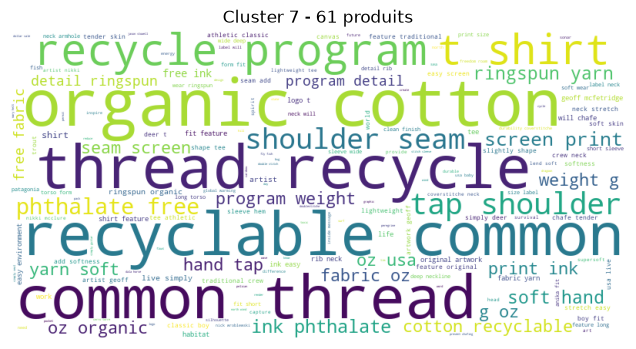

In [21]:
wordcloud_cluster(7)

In [22]:
# Essai du nuage de mots, mais en tenant compte du tf-idf
# devrait être plus spécifique au groupe car donne un poids moindre aux mots qui apparaissent dans tous les groupes 

feature_names = tfidf.get_feature_names_out()

def wordcloud_cluster_tfidf(cluster_id):
    mask = (data['cluster_dbscan'] == cluster_id).values
    X_cluster = X[mask]
    mean_tfidf = np.asarray(X_cluster.mean(axis=0)).flatten()
    word_scores = dict(zip(feature_names, mean_tfidf))

    wd = WordCloud(width=800, height=400, background_color='white')
    cloud = wd.generate_from_frequencies(word_scores)

    plt.figure(figsize=(8, 4))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(f'Cluster {cluster_id} - {mask.sum()} produits (TF-IDF)')
    plt.show()

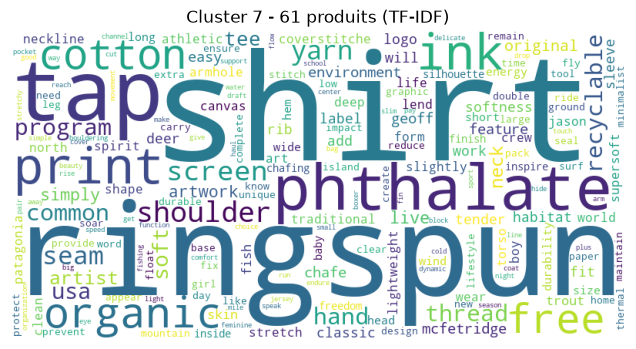

In [23]:
wordcloud_cluster_tfidf(7)

Cluster 7 (61 produits) : t-shirts en coton biologique (organic cotton, ringspun) avec impressions sérigraphiées (screen print, ink) et motifs d'artistes (artist, artwork). Le nuage TF-IDF fait mieux ressortir ces mots que celui basé sur les fréquences, dominé par le texte standard du catalogue (recyclable, common thread program).

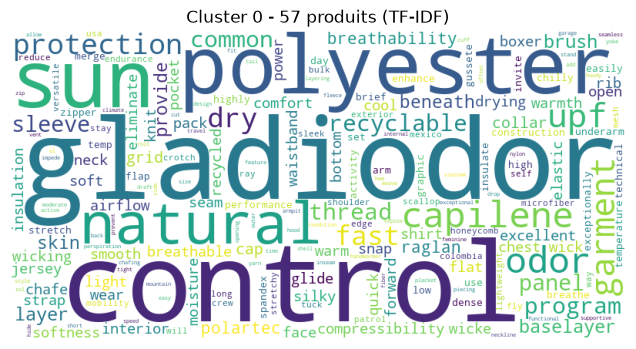

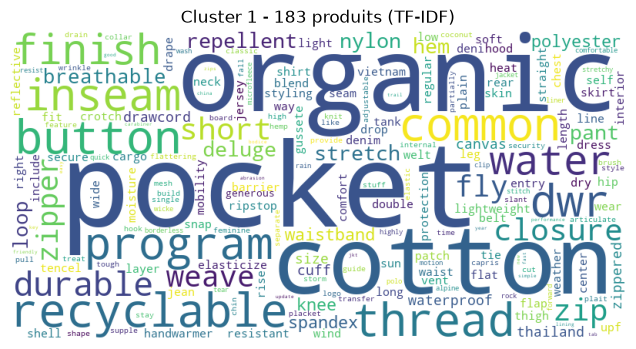

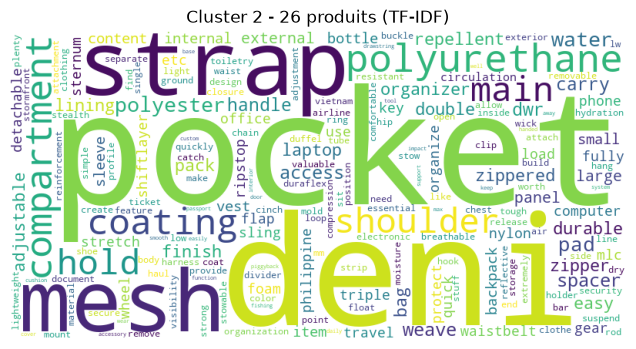

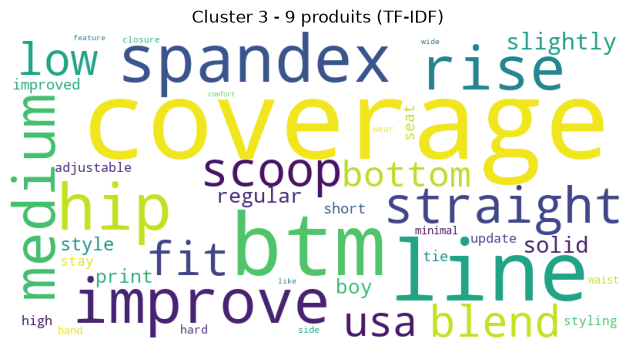

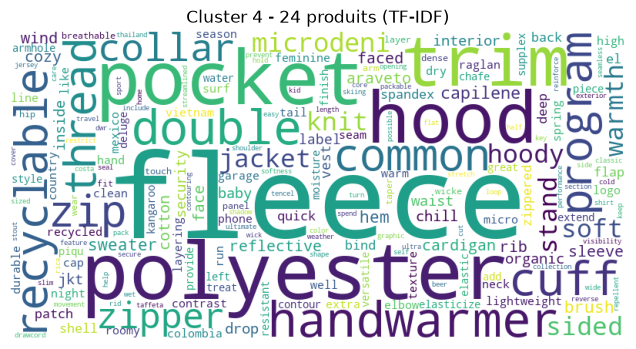

...

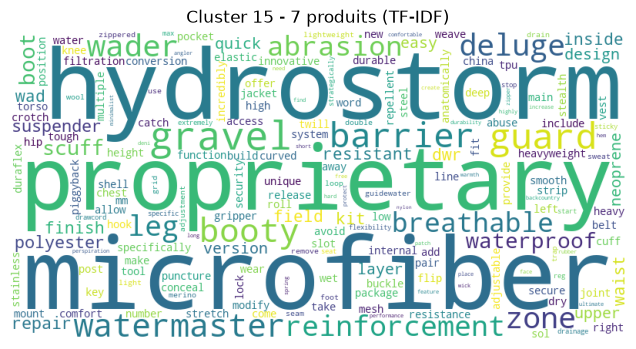

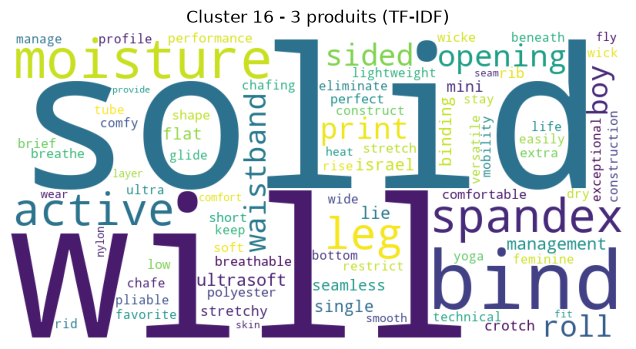

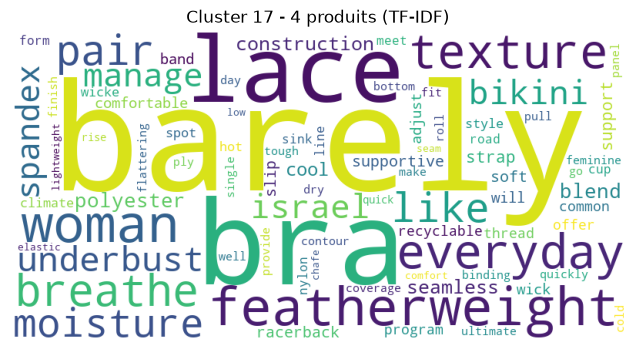

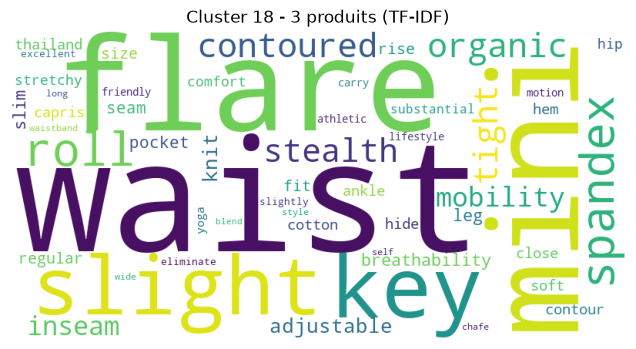

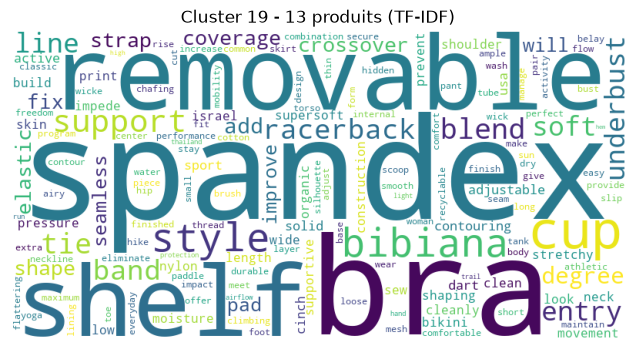

In [24]:
for i in range(20) :
    wordcloud_cluster_tfidf(i)

# Partie 2 : système de recommandation

In [25]:
data.sample(2)

,id,description,description_clean,cluster_dbscan
345,346,"Versatiliti tee - A free-moving, breathable an...",versatiliti tee free move breathable famously ...,1
280,281,Nine trails jkt - The Nine Trails Jacket is fo...,trail jkt trail jacket woman idea entertainmen...,1


In [26]:
data['name'] = data['description'].str.split(' - ').str[0]
data.head(2)

,id,description,description_clean,cluster_dbscan,name
0,1,Active classic boxers - There's a reason why o...,active classic boxer reason boxer cult favorit...,0,Active classic boxers
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer brief skin glory require mo...,0,Active sport boxer briefs


In [27]:
def find_similar_items(item_id, n=5):
    
    if item_id not in data['id'].values:
        print("index inconnu, veuillez reformuler votre demande")
        return None

    cluster = data.loc[data['id'] == item_id, 'cluster_dbscan'].iloc[0] #pour trouver le cluster

    if cluster == -1: #pour gérer les outliers
        print("ce produit est unique en son genre ! Nous n'avons pas de produit similaire à vous proposer")
        return []

    same_cluster_items = data[(data['cluster_dbscan'] == cluster) & (data['id'] != item_id)]

    n = min(n, len(same_cluster_items)) #pour les petits clusters de moins de 6 produits
    
    return same_cluster_items['id'].sample(n).tolist() 

In [28]:
find_similar_items(220)

[219, 291, 240, 254, 261]

In [29]:
reponse = input("Entrez l'id d'un produit : ")

if reponse.isdigit():
    item_id = int(reponse)
    suggestions = find_similar_items(item_id)

    if suggestions:
        item_name = data.loc[data['id'] == item_id, 'name'].iloc[0]
        print(f"Parce ce que vous vous intéressez à {item_id} - {item_name}, vous pourriez aussi aimer :")
        for one_id in suggestions:
            name = data.loc[data['id'] == one_id, 'name'].iloc[0]
            print(" - ", one_id, "-", name)
else:
    print("Veuillez entrer un id sous forme d'entier positif.")

Parce ce que vous vous intéressez à 219 - Solid adour btm, vous pourriez aussi aimer :
 -  254 - Solid paries btm
 -  8 - Print banded betina btm
 -  291 - Print adour btm
 -  220 - Solid betina btm
 -  262 - Print sunamee btm


### Système de recommandation

- la fonction find_similar_items retrouve le cluster DBSCAN du produit, puis renvoie 5 ids tirés au hasard parmi les autres produits du même cluster.
- Si l'id n'existe pas, la fonction renvoie `None`, avec un message ; si le produit est un outlier (cluster -1), elle renvoie une liste vide, avec un message.
- Dans les petits clusters (moins de 6 produits), la fonction renvoie moins de 5 suggestions.
- Le choix des recommandations se fait aléatoirement dans le cluster, une amélioration possible serait de recommander les produits les plus proches au sein du cluster.

# Partie 3 : extraction des sujets (topic modeling)

In [30]:
N_TOPICS = 15

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42)

topic_encoded = svd.fit_transform(X)

In [31]:
topic_names = []

for i in range(N_TOPICS):
    topic_names.append(f"topic_{i}")

topic_encoded_df = pd.DataFrame(topic_encoded, columns=topic_names)

topic_encoded_df.head()

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14
0,0.236608,-0.106444,0.186851,0.130442,-0.092742,0.026382,-0.092759,-0.015271,0.063784,-0.162370,-0.057001,-0.026943,-0.043566,0.053551,0.058783
1,0.282840,-0.118088,0.105594,0.128472,0.007798,0.172742,0.018087,-0.004189,0.007412,-0.162152,0.015387,0.027667,-0.060021,0.119392,-0.020339
2,0.270425,-0.141932,0.135716,0.047372,-0.003021,0.123028,0.100331,0.097539,-0.005864,-0.089703,-0.006594,0.090129,-0.089976,0.162664,0.015339
3,0.382258,-0.334578,-0.077051,-0.184691,0.054545,0.018997,0.015514,-0.165468,0.012862,-0.090913,0.025727,-0.165542,-0.108741,0.020487,-0.008338
4,0.366238,-0.333846,0.037290,-0.274537,-0.025341,-0.077573,0.057863,-0.059649,0.002283,-0.038671,0.111339,-0.279615,0.100175,0.277011,0.110166


In [32]:
main_topic = topic_encoded_df.idxmax(axis=1)

main_topic.value_counts()

topic_0     268
topic_6      41
topic_1      38
topic_2      37
topic_7      30
topic_3      14
topic_10     13
topic_4      13
topic_5      10
topic_13      9
topic_8       8
topic_9       7
topic_14      7
topic_11      5
Name: count, dtype: int64

Le sujet 0 (topic_0) est présent dans plus de la moitié des produits, il n'est pas très représentatif.
Dans la suite, on supprime le sujet 0 pour ne garder que les sujets plus pertinents.

In [33]:
topics_sans_0 = topic_encoded_df.drop(columns=['topic_0'])

main_topic = topics_sans_0.idxmax(axis=1)

main_topic.value_counts()

topic_6     71
topic_5     63
topic_1     62
topic_3     57
topic_2     44
topic_7     38
topic_9     36
topic_10    35
topic_13    30
topic_4     24
topic_11    12
topic_14    11
topic_12     9
topic_8      8
Name: count, dtype: int64

In [34]:
data['main_topic'] = main_topic

data.sample(10)

,id,description,description_clean,cluster_dbscan,name,main_topic
273,274,Torrentshell jkt - Tropical rain forests share...,torrentshell jkt tropical rain forest share th...,1,Torrentshell jkt,topic_12
210,211,"R2 jkt - A modern mountain staple, the adaptab...",jkt modern mountain staple adaptable jacket se...,0,R2 jkt,topic_2
117,118,Shop pants - reg - More at home under the truc...,shop pant reg home truck inside shop pant garm...,1,Shop pants,topic_3
218,219,"Solid adour btm - Adours feature a scooped, lo...",solid adour btm adour feature scoop low rise l...,3,Solid adour btm,topic_6
372,373,Permit silhouette t-shirt - The Permit's scyth...,permit silhouette t shirt permit scythe shape ...,7,Permit silhouette t-shirt,topic_1
377,378,"R1 full-zip jkt - It stretches, breathes, wick...",zip jkt stretch breathe wick warm wonder trail...,0,R1 full-zip jkt,topic_10
499,500,All-wear shorts - Time to simplify? Our All-We...,wear short time simplify wear short prove shor...,1,All-wear shorts,topic_3
220,221,Solid bibiana 1 piece - The sporty Bibiana One...,solid bibiana piece sporty bibiana piece racer...,19,Solid bibiana 1 piece,topic_6
492,493,'73 logo t-shirt - Patagonia's timeless '73 Lo...,logo t shirt patagonia timeless logo t shirt p...,7,'73 logo t-shirt,topic_1
379,380,Lw r4 jkt - High off the deck on Warbonnet Pea...,lw jkt high deck warbonnet peak immaculate win...,0,Lw r4 jkt,topic_10


In [35]:
print(svd.components_.shape)

poids_mots = pd.Series(svd.components_[6], index=feature_names)

poids_mots.sort_values(ascending=False).head(10)

(15, 1000)


spandex     0.336589
coverage    0.256098
line        0.195513
hip         0.184672
blend       0.164841
tencel      0.133231
bra         0.128334
neck        0.110391
btm         0.109806
improve     0.107938
dtype: float64

Pour le thème 6, les mots dominants sont spandex, coverage, hip, blend, tencel, bra, btm.

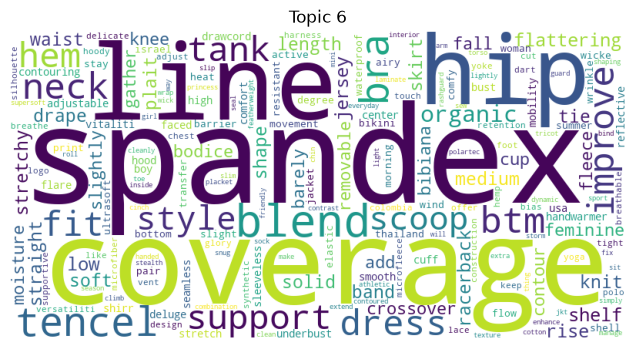

In [36]:
poids_mots = pd.Series(svd.components_[6], index=feature_names)

poids_positifs = poids_mots[poids_mots > 0]

word_scores = poids_positifs.to_dict()

wd = WordCloud(width=800, height=400, background_color='white')
cloud = wd.generate_from_frequencies(word_scores)

plt.figure(figsize=(8, 4))
plt.imshow(cloud)
plt.axis('off')
plt.title('Topic 6')
plt.show()

In [37]:
def wordcloud_topic(topic_id):
    poids_mots = pd.Series(svd.components_[topic_id], index=feature_names)
    poids_positifs = poids_mots[poids_mots > 0]
    word_scores = poids_positifs.to_dict()

    wd = WordCloud(width=800, height=400, background_color='white')
    cloud = wd.generate_from_frequencies(word_scores)

    nb_produits = (data['main_topic'] == f"topic_{topic_id}").sum()

    plt.figure(figsize=(8, 4))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(f'Topic {topic_id} - {nb_produits} produits')
    plt.show()

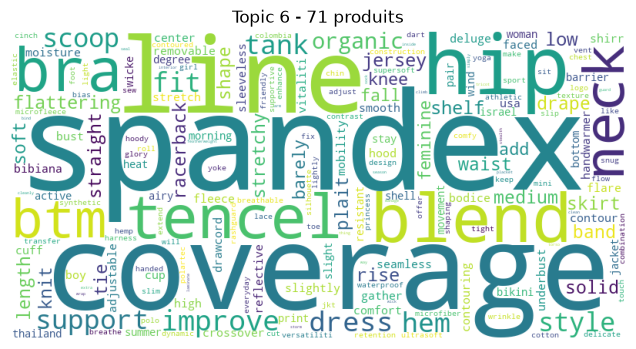

In [38]:
wordcloud_topic(6)

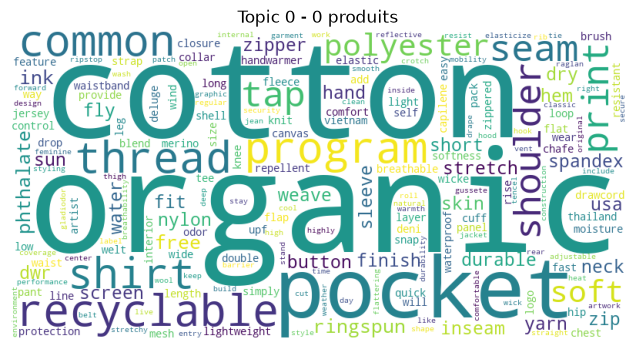

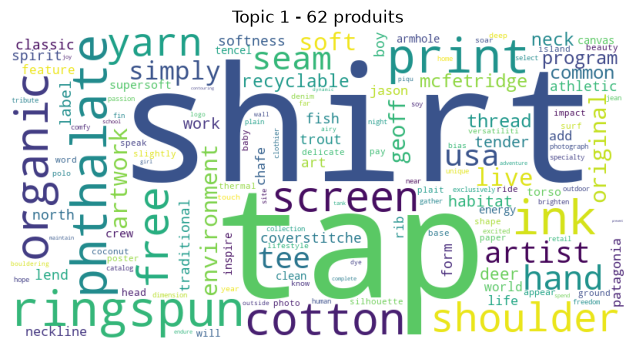

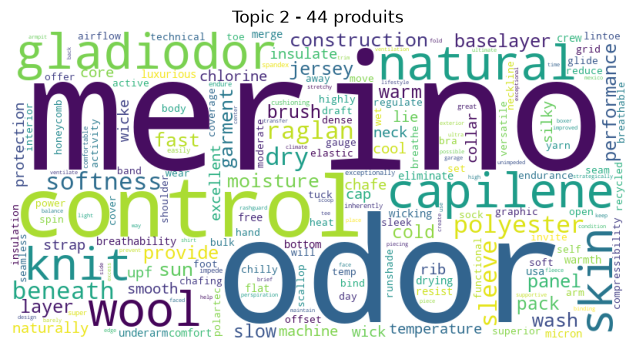

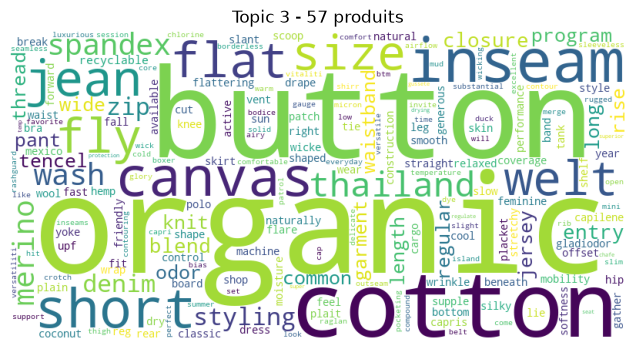

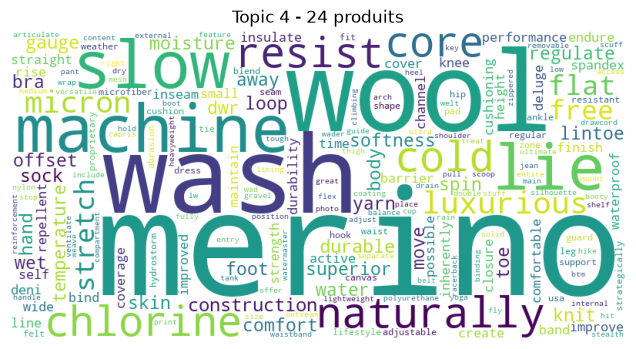

...

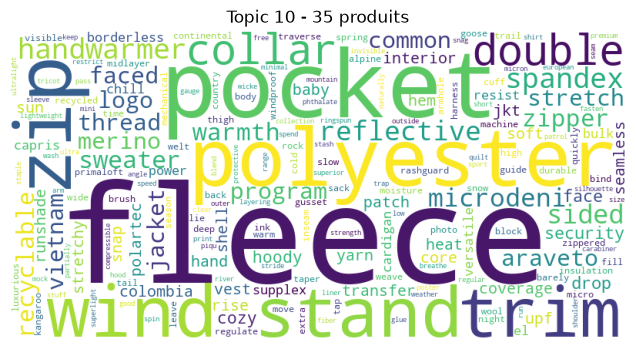

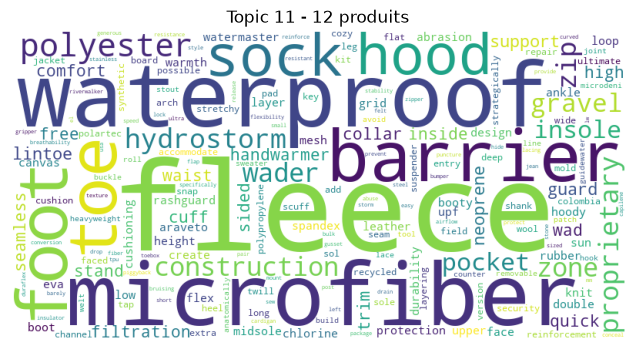

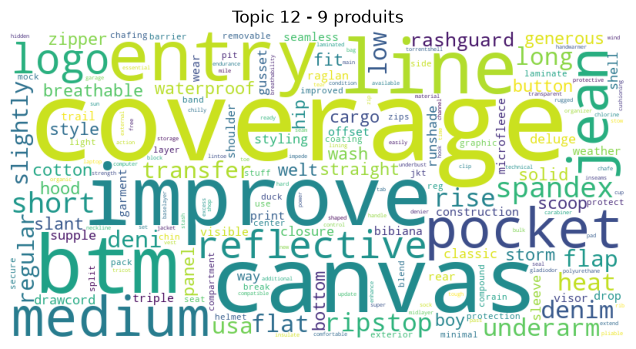

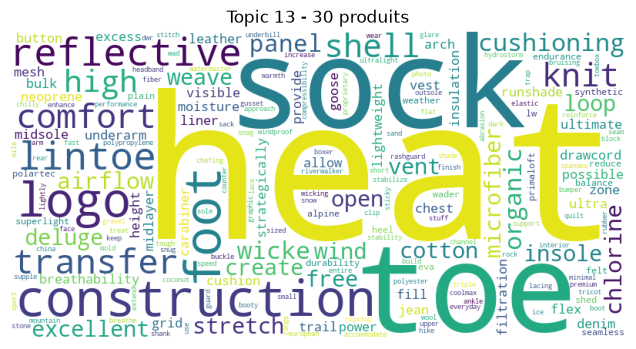

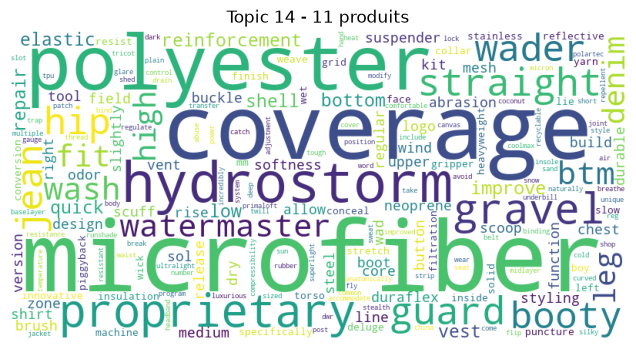

In [39]:
for i in range(N_TOPICS):
    wordcloud_topic(i)

In [40]:
for i in range(N_TOPICS):
    poids_mots = pd.Series(svd.components_[i], index=feature_names)
    meilleurs_mots = poids_mots.sort_values(ascending=False).head(8)
    liste_mots = list(meilleurs_mots.index)
    print(f"Topic {i} : {liste_mots}")

Topic 0 : ['organic', 'cotton', 'pocket', 'recyclable', 'common', 'program', 'thread', 'shirt']
Topic 1 : ['shirt', 'tap', 'ringspun', 'phthalate', 'print', 'ink', 'organic', 'cotton']
Topic 2 : ['merino', 'odor', 'control', 'gladiodor', 'capilene', 'natural', 'wool', 'skin']
Topic 3 : ['organic', 'button', 'cotton', 'inseam', 'canvas', 'short', 'jean', 'flat']
Topic 4 : ['merino', 'wool', 'wash', 'machine', 'slow', 'lie', 'naturally', 'chlorine']
Topic 5 : ['sun', 'upf', 'nylon', 'spandex', 'protection', 'coverage', 'inseam', 'print']
Topic 6 : ['spandex', 'coverage', 'line', 'hip', 'blend', 'tencel', 'bra', 'neck']
Topic 7 : ['strap', 'mesh', 'polyurethane', 'pad', 'compartment', 'deni', 'coating', 'shoulder']
Topic 8 : ['photo', 'poster', 'outside', 'print', 'human', 'photograph', 'soy', 'catalog']
Topic 9 : ['sun', 'protection', 'upf', 'collar', 'merino', 'photo', 'shirt', 'placket']
Topic 10 : ['fleece', 'pocket', 'polyester', 'zip', 'wind', 'stand', 'trim', 'collar']
Topic 11 : [

### Interprétation des topics

Le topic 0 capte le vocabulaire commun à tout le catalogue (coton bio, programme de recyclage...) : il est donc exclu du calcul du sujet principal de chaque produit.

Les sujets retenus d'après les mots-clés : 

| Sujet | Interprétation |
|---|---|
| 1 | T-shirts en coton bio imprimés |
| 2 | Sous-vêtements techniques en mérinos, anti-odeurs |
| 3 | Shorts et jeans en coton bio ou toile |
| 4 | Laine mérinos : consignes d'entretien |
| 5 | Maillots et vêtements anti-UV |
| 6 | Brassières et bas ajustés, tissus stretch |
| 7 | Sacs, gilets et accessoires à sangles |
| 8 | Texte sur les photos et affiches du catalogue |
| 9 | Chemises anti-UV (col, boutons) |
| 10 | Vestes et pulls en polaire |
| 11 | Chaussettes et accessoires en polaire ou imperméables |
| 12 | Pantalons et jeans en toile (thème moins net) |
| 13 | Chaussettes (détails réfléchissants) |
| 14 | Vêtements imperméables avec revêtement propriétaire |

Certains sujets se recoupent (5 et 9, 11 et 13), d'autres décrivent un texte répété du catalogue (8) plutôt qu'un type de produit. Contrairement au clustering, un produit est lié à plusieurs topics ; on ne retient ici que le topic principal.

# Conclusion

À partir des seules descriptions des 500 produits, on a pu :
- regrouper les produits par familles : 20 groupes de produits aux descriptions proches ;
- proposer des recommandations sur chaque fiche produit : pour un produit donné, le système suggère jusqu'à 5 articles de la même famille ;
- faire apparaître les grands thèmes du catalogue : matières (mérinos, polaire, coton bio), usages (protection solaire, imperméabilité) et types de produits (sacs, chaussettes, maillots).

Cela pourraut permettre aux webmasters :
- d'afficher des « vous pourriez aussi aimer » sans avoir à classer le catalogue à la main.
- de réorganiser le site avec de nouvelles catégories fondées sur les thèmes trouvés (par exemple « anti-UV », « mérinos », « chaussettes »).
et pour les responsables du catalogue : 
- de repérer 41 produits atypiques (8 % du catalogue), qui ne ressemblent à aucun autre
- de retravailler leur description ou de les mettre en avant comme "unique".

### Les limites
- Le premier cluster est trop large : il rassemble 183 produits (37 % du catalogue), donc ses recommandations sont peu précises.
- Les 41 produits atypiques n'ont aucune recommandation.
- Les suggestions sont choisies au hasard dans le cluster, on pourrait envisager des suggestions plus proches.
- Certains thèmes se recoupent (par exemple les vêtements anti-UV et les chaussettes se retrouvent dans deux thèmes chacun). Cela reflète des phrases répétées du catalogue plutôt qu'un vrai type de produit.